In [1]:
# Bibliotecas utilizadas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

c:\Users\Yan\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.stats import gaussian_kde


In [2]:
df = pd.read_csv("E-commerce Website Logs.csv",na_values=["--"], dtype={"age": "Int64"})
df

,accessed_date,duration_(secs),network_protocol,ip,bytes,accessed_Ffom,age,gender,country,membership,language,sales,returned,returned_amount,pay_method
0,2017-03-14 17:43:57.172,2533,TCP,1.10.195.126,20100,Chrome,28,Female,CA,Normal,English,261.9600,No,0.00,Credit Card
1,2017-03-14 17:43:57.172,4034,TCP,1.1.217.211,20500,Mozilla Firefox,21,Male,AR,Normal,English,731.9400,No,0.00,Debit Card
2,2017-03-14 17:43:26.135,1525,TCP,1.115.198.107,90100,Mozilla Firefox,20,Male,PL,Normal,English,14.6200,No,0.00,Cash
3,2017-03-14 17:43:26.135,4572,TCP,1.121.152.143,100300,Mozilla Firefox,66,Female,IN,Normal,Spanish,957.5775,No,0.00,Credit Card
4,2017-03-14 18:17:09.005,3652,TCP,1.123.135.213,270200,Mozilla Firefox,53,Female,KR,Normal,Spanish,22.3680,No,0.00,Cash
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172833,2017-03-16 11:42:01.298,4372,TCP,94.197.121.229,100600,Android App,<NA>,Male,US,Normal,English,0.0000,Yes,143.36,Debit Card
172834,2017-03-16 12:10:17.340,2167,TCP,129.110.241.72,30400,Android App,<NA>,Female,IT,Normal,English,15.1500,No,0.00,Cash
172835,2017-03-16 12:10:17.340,2725,TCP,185.119.252.121,100300,Android App,<NA>,Female,IT,Normal,English,600.1600,No,0.00,Credit Card
172836,2017-03-16 15:52:58.342,3728,TCP,185.145.107.23,50200,Android App,<NA>,Male,US,Normal,Russian,75.7500,No,0.00,Cash


# Relação entre acesso X dia

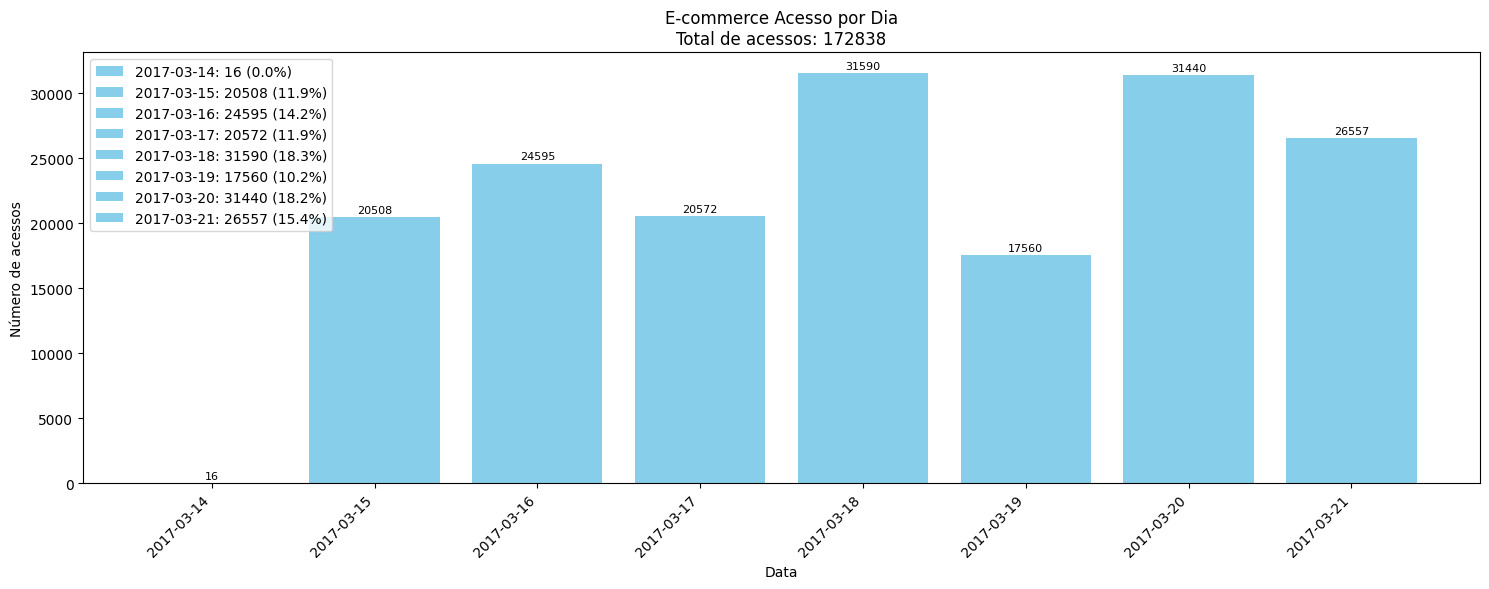

In [36]:
a = pd.to_datetime(df["accessed_date"], errors="coerce").dt.date

acessos_por_data = a.value_counts().sort_index()

datas = [str(d) for d in acessos_por_data.index] 
quantidades = acessos_por_data.values
total = quantidades.sum()

plt.figure(figsize=(15,6))

bars = plt.bar(datas, quantidades, color="skyblue")

for i, v in enumerate(quantidades):
    plt.text(i, v + max(quantidades)*0.01, str(v), ha="center", fontsize=8)

plt.xlabel("Data")
plt.ylabel("Número de acessos")
plt.title(f"E-commerce Acesso por Dia\nTotal de acessos: {total}")

plt.legend(
    bars,
    [f"{datas[i]}: {quantidades[i]} ({quantidades[i]*100/total:.1f}%)" for i in range(len(datas))]
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Análise da variável duration_(secs)

In [6]:
Max = df["duration_(secs)"].max()
Min = df["duration_(secs)"].min()
mean = df["duration_(secs)"].mean()

print(f"Min: {Min}s ({Min/60:.2f}min)\nmax: {Max}s ({Max/60:.2f}min)\nMean: {mean:.2f}s ({mean/60:.2f}min)")

Min: 1500s (25.00min)
max: 5000s (83.33min)
Mean: 3248.03s (54.13min)


# Relação entre acesso x protocolo

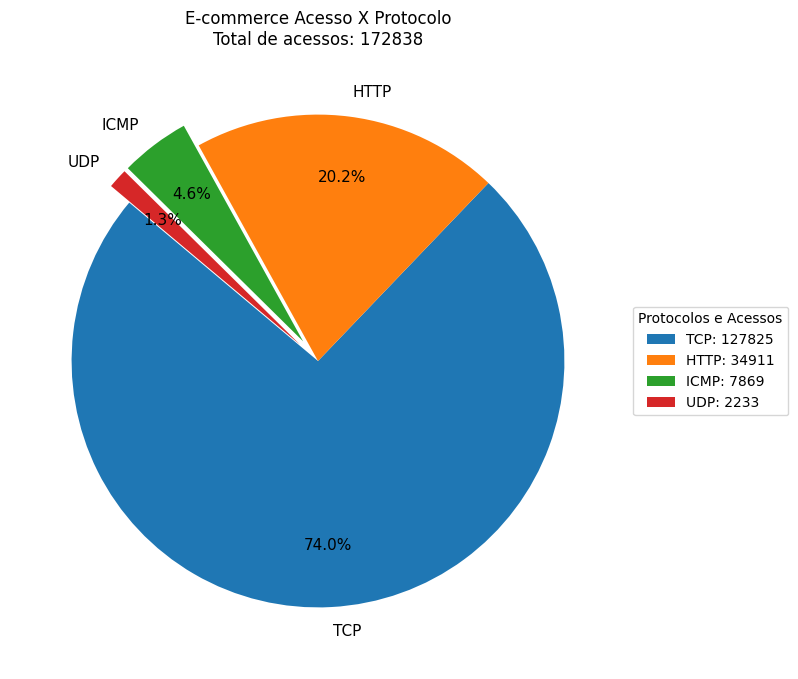

In [7]:
df["network_protocol"] = df["network_protocol"].str.strip()
protocolos = df["network_protocol"].value_counts()

explode = [0.1 if (v / total) < 0.05 else 0 for v in protocolos.values]

plt.figure(figsize=(8, 8))

plt.pie(
    protocolos.values,
    labels=protocolos.index,
    autopct="%1.1f%%",
    startangle=140,
    explode=explode,
    textprops={'fontsize': 11},
    pctdistance=0.75
)
legendas_com_valores = [f"{protocolo}: {quantidade}" for protocolo, quantidade in protocolos.items()]

plt.legend(
    legendas_com_valores, 
    title="Protocolos e Acessos", 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1) # Ajusta a posição para fora da pizza
)

plt.title(f"E-commerce Acesso X Protocolo\nTotal de acessos: {total}")
plt.show()

# Relação entre acesso X navegador 

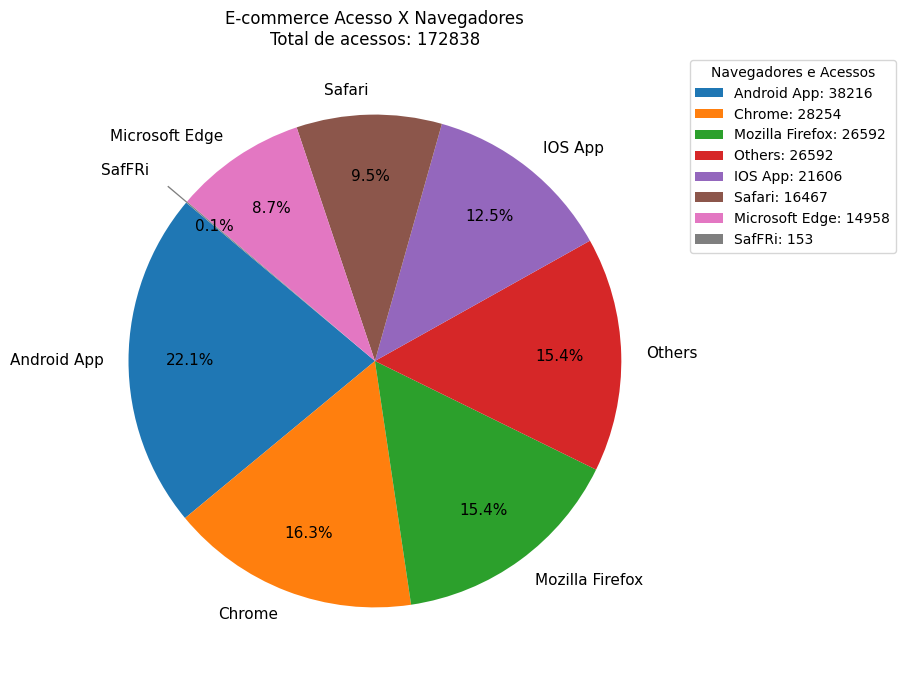

In [8]:
df["accessed_Ffom"] = df["accessed_Ffom"].str.strip()
navegadores = df["accessed_Ffom"].value_counts()

explode = [0.1 if (v / total) < 0.05 else 0 for v in navegadores.values]

plt.figure(figsize=(8, 8))

plt.pie(
    navegadores.values,
    labels=navegadores.index,
    autopct="%1.1f%%",
    startangle=140,
    explode=explode,
    textprops={'fontsize': 11},
    pctdistance=0.75
)
legendas_com_valores = [f"{navegadores}: {quantidade}" for navegadores, quantidade in navegadores.items()]

plt.legend(
    legendas_com_valores, 
    title="Navegadores e Acessos", 
    loc="upper left", 
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title(f"E-commerce Acesso X Navegadores\nTotal de acessos: {total}")
plt.show()

# Relação entre acesso X idade 

min: 18
max: 69
mean: 43.44
Intervalos calculados: [(17.949, 35.0], (52.0, 69.0], (35.0, 52.0], NaN]
Categories (3, interval[float64, right]): [(17.949, 35.0] < (35.0, 52.0] < (52.0, 69.0]]


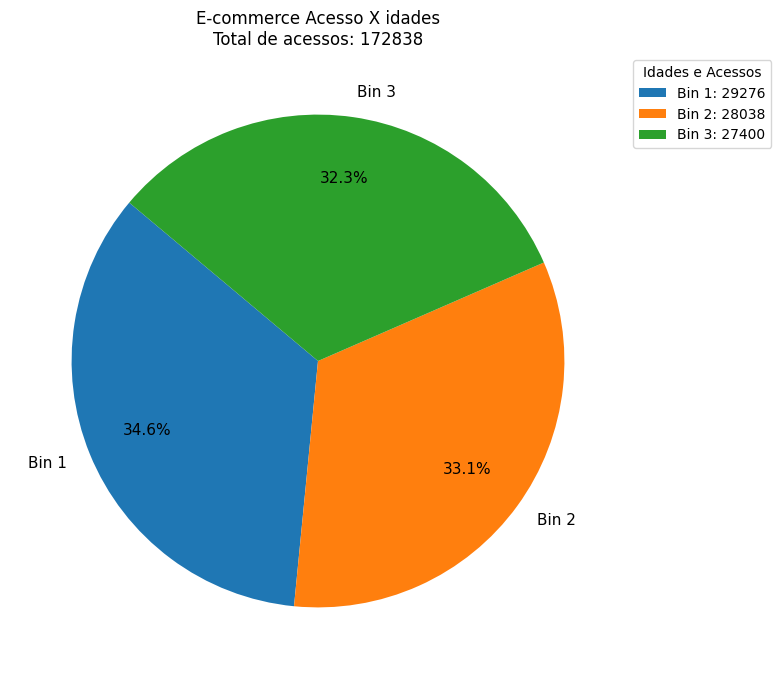

In [9]:
idades = df["age"].value_counts()

Max = df["age"].max()
Min = df["age"].min()
mean = df["age"].mean()

print(f'min: {Min}\nmax: {Max}\nmean: {mean:.2f}')

faixa_etaria = pd.cut(df['age'], bins=3, labels=['Bin 1', 'Bin 2', 'Bin 3'])

intervalos_reais = pd.cut(df['age'], bins=3).unique()
print(f"Intervalos calculados: {intervalos_reais}")


explode = [0.1 if (v / total) < 0.05 else 0 for v in faixa_etaria.value_counts().values]

plt.figure(figsize=(8, 8))

plt.pie(
    faixa_etaria.value_counts().values,
    labels=faixa_etaria.value_counts().index,
    autopct="%1.1f%%",
    startangle=140,
    explode=explode,
    textprops={'fontsize': 11},
    pctdistance=0.75
)
legendas_com_valores = [f"{idade}: {quantidade}" for idade, quantidade in faixa_etaria.value_counts().items()]

plt.legend(
    legendas_com_valores, 
    title="Idades e Acessos", 
    loc="upper left", 
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title(f"E-commerce Acesso X idades\nTotal de acessos: {total}")
plt.show()

# Relação entre acesso X gênero


In [34]:
df['gender'].value_counts().index

Index(['Female', 'Male', 'Unknown'], dtype='object', name='gender')

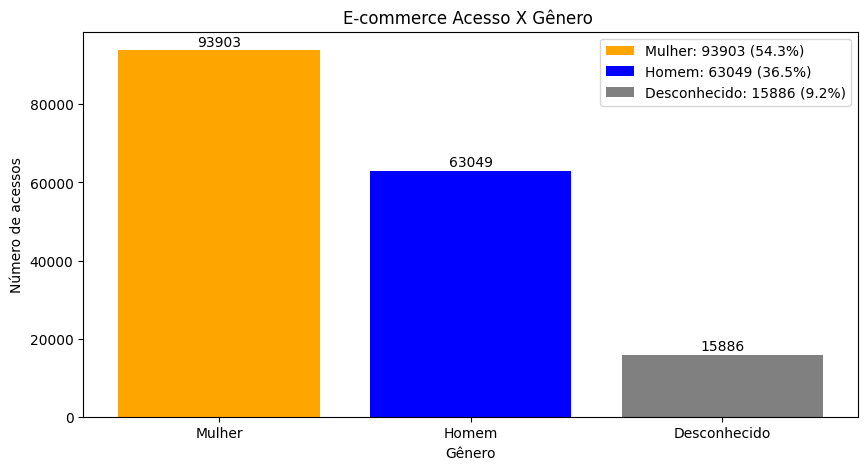

In [35]:
plt.figure(figsize=(10,5))

bars = plt.bar(["Mulher", "Homem", "Desconhecido"], df['gender'].value_counts().values, color=["orange", "blue", "gray"])

mulher = len(df[df["gender"] == "Female"])
homem = len(df[df["gender"] == "Male"])
desconhecido = len(df[df["gender"] == "Unknown"])
total = len(df["gender"])

plt.text(0, mulher+1000, str(mulher), ha="center")
plt.text(1, homem+1000, str(homem), ha="center")
plt.text(2, desconhecido+1000, str(desconhecido), ha="center")

plt.xlabel("Gênero")
plt.ylabel("Número de acessos")
plt.title("E-commerce Acesso X Gênero ")

plt.legend(bars, [f"Mulher: {mulher} ({mulher * 100 / total:.1f}%)",f"Homem: {homem} ({homem * 100 / total:.1f}%)",f"Desconhecido: {desconhecido} ({desconhecido * 100 / total:.1f}%)",f"Total: {total}"])

plt.show()

# Relação entre acesso X país  

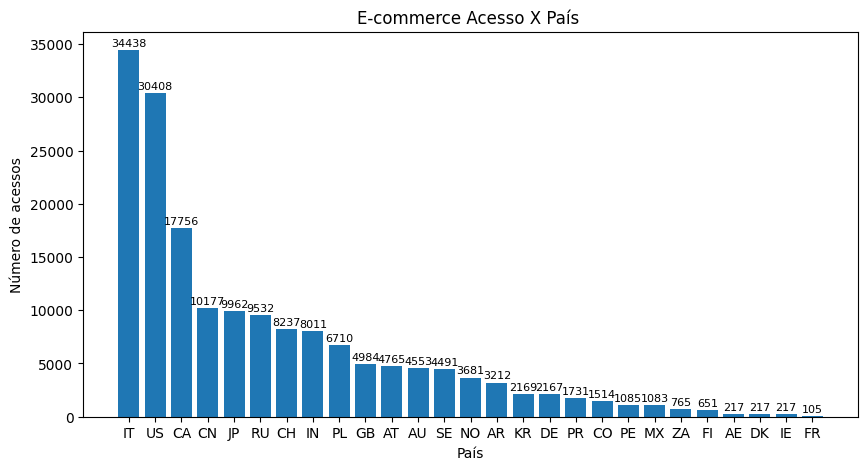

In [15]:
cidades = df['country'].value_counts()

plt.figure(figsize=(10,5))

bars = plt.bar(cidades.index, cidades.values)

total = len(df["country"])
quantidades = cidades.values
for i, v in enumerate(quantidades):
    plt.text(i, v + max(quantidades)*0.01, str(v), ha="center", fontsize=8)

plt.xlabel("País")
plt.ylabel("Número de acessos")
plt.title("E-commerce Acesso X País ")

plt.show()

# Relação entre acesso X membership 

In [12]:
df["membership"].unique()

array(['Normal', 'Premium', 'Not Logged In'], dtype=object)

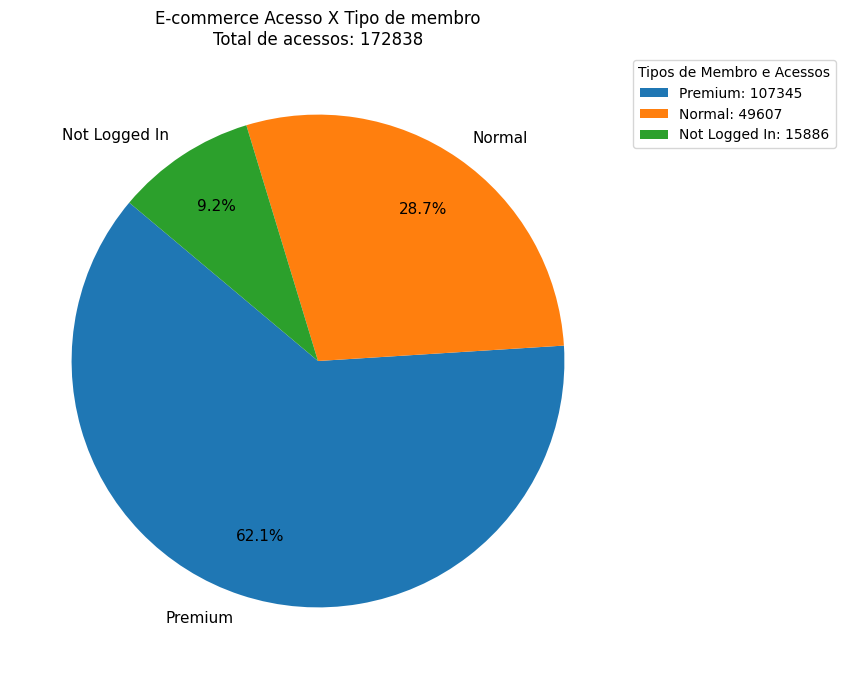

In [19]:
tipos = df["membership"].value_counts()

total = len(df)

explode = [0.1 if (v / total) < 0.05 else 0 for v in tipos.values]

plt.figure(figsize=(8, 8))

plt.pie(
    tipos.values,
    labels=tipos.index,
    autopct="%1.1f%%",
    startangle=140,
    explode=explode,
    textprops={'fontsize': 11},
    pctdistance=0.75
)
legendas_com_valores = [f"{tipo}: {quantidade}" for tipo, quantidade in tipos.items()]

plt.legend(
    legendas_com_valores, 
    title="Tipos de Membro e Acessos", 
    loc="upper left", 
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title(f"E-commerce Acesso X Tipo de membro\nTotal de acessos: {total}")
plt.show()

# Relação entre acesso X linguagem

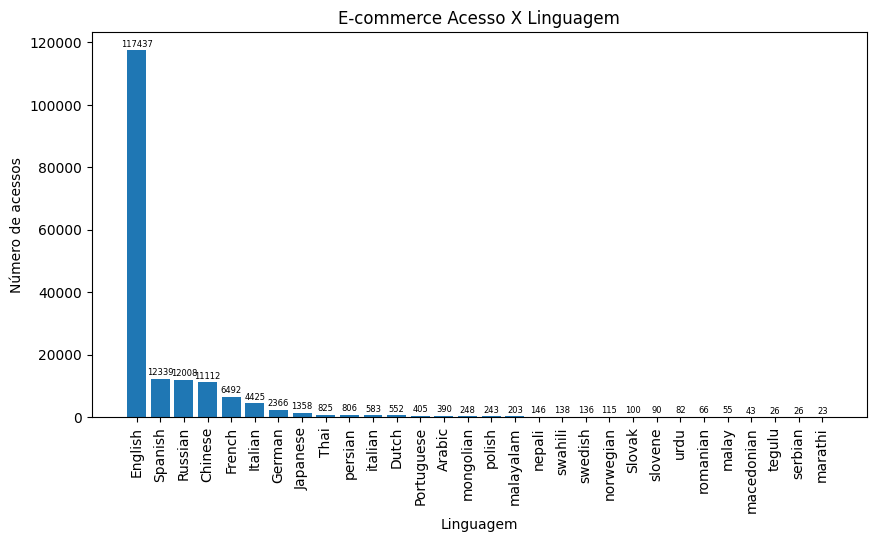

In [27]:
cidades = df['language'].value_counts()

plt.figure(figsize=(10,5))

bars = plt.bar(cidades.index, cidades.values, )

total = len(df)
quantidades = cidades.values
for i, v in enumerate(quantidades):
    plt.text(i, v + max(quantidades)*0.01, str(v), ha="center", fontsize=6)

plt.xlabel("Linguagem")
plt.xticks(rotation=90)
plt.ylabel("Número de acessos")
plt.title("E-commerce Acesso X Linguagem")

plt.show()

# Análise da variável sales

In [ ]:
Max = df["sales"].max()
Min = df["sales"].min()
mean = df["sales"].mean()

print(f"Min: {Min:.2f}\nMax: {Max:.2f}\nMean: {mean:.2f}")

Min: 0.00
max: 11199.97
Mean: 411.35


# Relação entre acesso x metodo de pagamento pizza

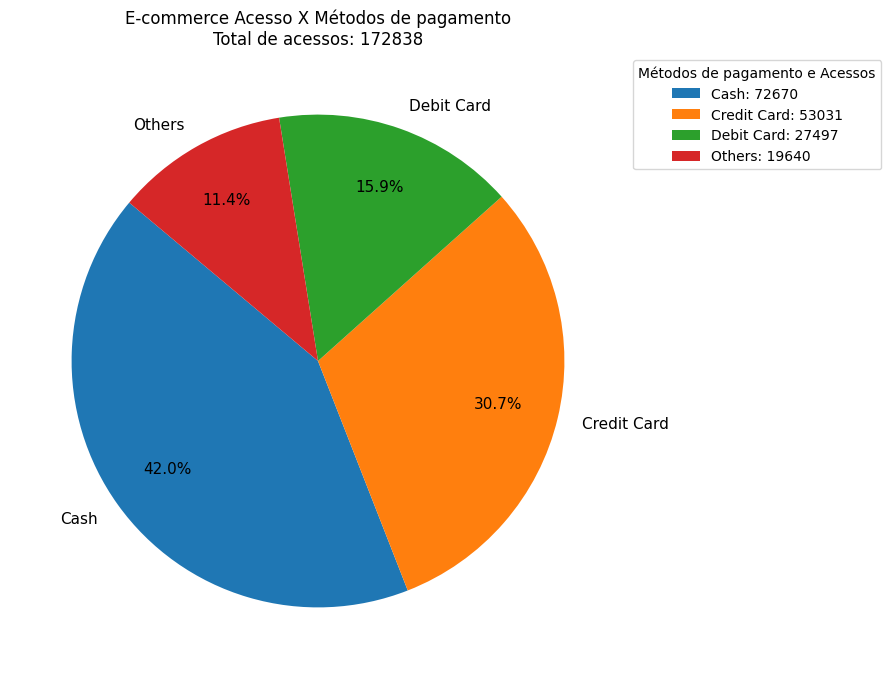

In [33]:
metodos_pag = df["pay_method"].value_counts()

total = len(df)

explode = [0.1 if (v / total) < 0.05 else 0 for v in metodos_pag.values]

plt.figure(figsize=(8, 8))

plt.pie(
    metodos_pag.values,
    labels=metodos_pag.index,
    autopct="%1.1f%%",
    startangle=140,
    explode=explode,
    textprops={'fontsize': 11},
    pctdistance=0.75
)
legendas_com_valores = [f"{tipo}: {quantidade}" for tipo, quantidade in metodos_pag.items()]

plt.legend(
    legendas_com_valores, 
    title="Métodos de pagamento e Acessos", 
    loc="upper left", 
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title(f"E-commerce Acesso X Métodos de pagamento\nTotal de acessos: {total}")
plt.show()